In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/naveenkumar20bps1137/sample-superstore/Sample_ Superstore.csv


# Project Overview

This project analyzes sales data to understand business performance and identify key problems affecting profitability.

The main goal is to explore sales, profit, and discount patterns and find areas where the business is losing money.

# Dataset Description 
This dataset contains transactional sales data from a retail store and is used to analyze business performance.
Below is a preview of the data structure

In [3]:
dataset = pd.read_csv("/kaggle/input/datasets/naveenkumar20bps1137/sample-superstore/Sample_ Superstore.csv")
print(dataset.shape)
print(dataset.columns)
dataset.head(5)

(9994, 19)
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Segment', 'Country', 'City', 'State', 'Region',
       'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales',
       'Quantity', 'Discount', 'Profit'],
      dtype='object')


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Corporate,United States,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


The dataset contains around 10,000 sales records and 19 columns.

Key fields include:
- Sales – total revenue from each order
- Profit – profit generated from each order
- Discount – discount applied to the order
- Category and Sub-Category – product classification
- Region – geographical area

The dataset allows analysis of business performance across products and regions.

# Data Cleaning

The dataset was checked for missing values and data consistency.

Date columns were converted to datetime format and basic validation checks were performed.

In [14]:
missing_values = dataset.isnull().sum()
duplicates = dataset.duplicated().sum()
print(missing_values)
print(duplicates)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Row ID          0
Order ID        0
Order Date      0
Ship Date       0
Ship Mode       0
Customer ID     0
Segment         0
Country         0
City            0
State           0
Region          0
Product ID      0
Category        0
Sub-Category    0
Product Name    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64
0


#### The dataset contains no significant missing values or duplicates.

# Exploratory Data Analysis

## Sales vs Profit

In [7]:
sales_sum = (dataset['Sales'].sum().round()) / 1000
profit_sum = (dataset['Profit'].sum().round()) / 1000

difference = sales_sum - profit_sum
procent = ((profit_sum / sales_sum) * 100).round(2)

print(f"The company sells a total of {sales_sum} thousand, but profits amount to only {profit_sum} thousand. The difference between sales and profit is {difference} thousand. Profit is only {procent}% of total sales.")

The company sells a total of 2297.201 thousand, but profits amount to only 286.397 thousand. The difference between sales and profit is 2010.804 thousand. Profit is only 12.47% of total sales.


Total sales are around 2.3M, while total profit is only about 286K (~12.5%).

This indicates relatively low profitability compared to total revenue.

## Category Analysis

In [8]:
sales_by_category = ((dataset.groupby('Category')['Sales'].sum() ) / 1000).round(2) 
profit_by_category = ((dataset.groupby('Category')['Profit'].sum() ) / 1000).round(2) 
sales_by_category_prc = ((sales_by_category / sales_sum) * 100).round(2)
profit_by_category_prc = ((profit_by_category / profit_sum) * 100).round(2)
print("Sales by Category:")
print(sales_by_category)
print("Profit by Category:")
print(profit_by_category)
print("Sales by Category percents:")
print(sales_by_category_prc)
print("Profit by Category percents:")
print(profit_by_category_prc)

Sales by Category:
Category
Furniture          742.00
Office Supplies    719.05
Technology         836.15
Name: Sales, dtype: float64
Profit by Category:
Category
Furniture           18.45
Office Supplies    122.49
Technology         145.45
Name: Profit, dtype: float64
Sales by Category percents:
Category
Furniture          32.3
Office Supplies    31.3
Technology         36.4
Name: Sales, dtype: float64
Profit by Category percents:
Category
Furniture           6.44
Office Supplies    42.77
Technology         50.79
Name: Profit, dtype: float64


Total sales are around 2.3M, while profit will be only around 286k, which is around 12.5% of total.
This suggests relatively low profitability and can indicate that costs or discounts may have significant impact on profit. 
Sales are relatively similar across categories, with Technology slightly leading.
Furniture generates around 32% of total sales but only 6% of total profit, making it the least efficient category.
In contrast, Technology is the most profitable, generating around 50% of total profit.

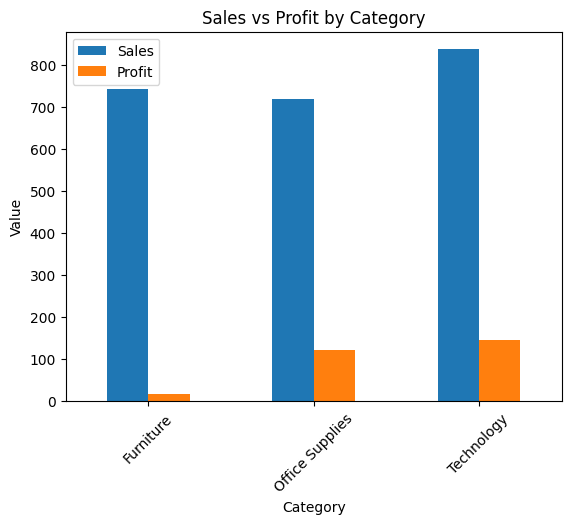

In [9]:
sales_vs_profit = pd.merge(sales_by_category, profit_by_category, on="Category")

sales_vs_profit.plot(kind="bar")
plt.title("Sales vs Profit by Category")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.show()

Sales are similar across categories, but profitability differs significantly.

Furniture generates a large portion of sales but very little profit, making it the least efficient category.

Technology is the most profitable category.

## Sub-Category Analysis

In [10]:
sales_by_subcategory = ((dataset.groupby('Sub-Category')['Sales'].sum() ) / 1000).round(2) 
profit_by_subcategory = ((dataset.groupby('Sub-Category')['Profit'].sum() ) / 1000).round(2)

print("SALES")
print(sales_by_subcategory.sort_values())
print("PROFIT")
print(profit_by_subcategory.sort_values())

SALES
Sub-Category
Fasteners        3.02
Labels          12.49
Envelopes       16.48
Art             27.12
Supplies        46.67
Paper           78.48
Furnishings     91.71
Appliances     107.53
Bookcases      114.88
Copiers        149.53
Accessories    167.38
Machines       189.24
Binders        203.41
Tables         206.97
Storage        223.84
Chairs         328.45
Phones         330.01
Name: Sales, dtype: float64
PROFIT
Sub-Category
Tables        -17.73
Bookcases      -3.47
Supplies       -1.19
Fasteners       0.95
Machines        3.38
Labels          5.55
Art             6.53
Envelopes       6.96
Furnishings    13.06
Appliances     18.14
Storage        21.28
Chairs         26.59
Binders        30.22
Paper          34.05
Accessories    41.94
Phones         44.52
Copiers        55.62
Name: Profit, dtype: float64


Several sub-categories generate losses, with Tables being the most problematic (-17.7K), followed by Bookcases and Supplies.

This suggests structural issues in pricing, costs, or discount strategy for these products.

Tables stand out as the biggest loss driver, indicating a serious inefficiency in this product segment.

## Profit Margin

In [11]:
profit_margin = (profit_by_subcategory / sales_by_subcategory).round(2).sort_values()
print(profit_margin)

Sub-Category
Tables        -0.09
Bookcases     -0.03
Supplies      -0.03
Machines       0.02
Chairs         0.08
Storage        0.10
Phones         0.13
Furnishings    0.14
Binders        0.15
Appliances     0.17
Art            0.24
Accessories    0.25
Fasteners      0.31
Copiers        0.37
Envelopes      0.42
Paper          0.43
Labels         0.44
dtype: float64


In [12]:
mean_discount_by_subcategory = dataset.groupby('Sub-Category')['Discount'].mean().round(2).sort_values()
print(mean_discount_by_subcategory)

Sub-Category
Art            0.07
Storage        0.07
Paper          0.07
Labels         0.07
Fasteners      0.08
Accessories    0.08
Envelopes      0.08
Supplies       0.08
Furnishings    0.14
Phones         0.15
Copiers        0.16
Chairs         0.17
Appliances     0.17
Bookcases      0.21
Tables         0.26
Machines       0.31
Binders        0.37
Name: Discount, dtype: float64


Profit margin varies significantly across products.

Some categories have negative margins, while others (e.g. Copiers, Paper) are highly profitable.

This shows that not all revenue contributes equally to profit. 
This highlights large differences in profitability between products.

## Profit Margin vs Discount
The table below shows the relationship between average discount and profit margin across sub-categories.

In [13]:
concated_kurcze = profit_margin.to_frame().join(mean_discount_by_subcategory)
print(concated_kurcze)

                 0  Discount
Sub-Category                
Tables       -0.09      0.26
Bookcases    -0.03      0.21
Supplies     -0.03      0.08
Machines      0.02      0.31
Chairs        0.08      0.17
Storage       0.10      0.07
Phones        0.13      0.15
Furnishings   0.14      0.14
Binders       0.15      0.37
Appliances    0.17      0.17
Art           0.24      0.07
Accessories   0.25      0.08
Fasteners     0.31      0.08
Copiers       0.37      0.16
Envelopes     0.42      0.08
Paper         0.43      0.07
Labels        0.44      0.07


To better understand the relationship between discounts and profitability, profit margin was compared with average discount per sub-category.

In general, higher discounts are associated with lower profit margins.  
For example, Tables and Bookcases have relatively high discounts and negative margins, which suggests that discounting contributes to losses.

However, this relationship is not always consistent.  
Some categories (like Supplies) have low discounts but still generate negative profit, which indicates deeper issues such as pricing or cost structure.

This shows that discounts are an important factor, but not the only reason for poor profitability.

# Business Insights


- Sales are high, but profitability is relatively low (~12.5%)
- Furniture is the least efficient category
- Tables and Bookcases generate significant losses
- Higher discounts generally reduce profitability
- Some categories (e.g. Supplies) generate losses even with low discounts

These findings suggest issues in pricing, discount strategy, and cost structure.

# Conclusion


The analysis shows that the company’s main problem is not sales, but profitability.

Improving pricing strategy, controlling discounts, and reviewing low-performing product categories could significantly increase overall profit.

Further analysis could include predictive modeling or customer segmentation.